# Рост ошибки прогноза в зависимости от горизонта

Этот ноутбук строит рост ошибки модели относительно точных орбитальных положений GNSS SP3 при увеличении горизонта прогноза.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
REPO_URL = 'https://github.com/Gavr101/space_modeling.git'


def run(cmd):
    print('>>', ' '.join(cmd))
    subprocess.check_call(cmd)


def find_project_root(start):
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'dynamics').is_dir() and (candidate / 'visualization').is_dir():
            return candidate
    raise RuntimeError(f'Cannot find project root from {start}')


if IN_COLAB:
    PROJECT_ROOT = Path('/content/space_modeling')
    if not PROJECT_ROOT.exists():
        run(['git', 'clone', REPO_URL, str(PROJECT_ROOT)])
    os.chdir(PROJECT_ROOT)

    run([sys.executable, '-m', 'pip', 'install', '--upgrade', 'pip'])
    run([sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt'])
    run([sys.executable, '-m', 'pip', 'install', '-e', '.'])
    # Опционально: NRLMSISE-00 улучшает моделирование плотности для сопротивления, если доступна.
    try:
        run([sys.executable, '-m', 'pip', 'install', 'nrlmsise00'])
    except Exception as exc:
        print('Optional dependency nrlmsise00 was not installed:', exc)
else:
    PROJECT_ROOT = find_project_root(Path.cwd())
    os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('Working dir:', Path.cwd())


Working dir: C:\Users\Gavriil\VS_projects\space_modeling


## Эталонные данные точных орбит

`VELOCITY_REFERENCE_SOURCES` используется совместно с демонстрацией распространения и содержит только продукты с исходными записями скоростей: Swarm SP3, CASSIOPE/Swarm-E SP3 и Sentinel-1 POEORB EOF. GNSS CODE MGEX хранится отдельно как опциональный источник только положений, потому что в этом продукте нет записей скоростей SP3.

In [2]:
import sys
from dataclasses import replace
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'dynamics').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dynamics.eof import eof_state_samples, read_sentinel_eof
from dynamics import make_addition_force_configs, make_recommended_force_config
from dynamics.experiment_results import make_experiment_record, write_experiment_summary
from dynamics.propagator import (
    PropagationConfig,
    SpacecraftProperties,
    propagate_orbit,
)
from dynamics.sp3 import download_sp3, read_sp3, sp3_state_samples


In [3]:
VELOCITY_REFERENCE_SOURCES = {
    'Sentinel-1A': {
        'format': 'sentinel_eof',
        'url': 'https://s1-orbits.s3.us-west-2.amazonaws.com/AUX_POEORB/S1A_OPER_AUX_POEORB_OPOD_20230821T080724_V20230731T225942_20230802T005942.EOF',
        'path': PROJECT_ROOT / 'data' / 'eof' / 'S1A_OPER_AUX_POEORB_OPOD_20230821T080724_V20230731T225942_20230802T005942.EOF',
        'requires_velocity': True,
        'velocity_source': 'sentinel_eof_osv',
        'spacecraft': SpacecraftProperties(mass=2185.0, cd=2.2, cr=1.3, reference_area=10.3),
    },
    'Sentinel-1B': {
        'format': 'sentinel_eof',
        'url': 'https://s1-orbits.s3.us-west-2.amazonaws.com/AUX_POEORB/S1B_OPER_AUX_POEORB_OPOD_20210203T112353_V20210113T225942_20210115T005942.EOF',
        'path': PROJECT_ROOT / 'data' / 'eof' / 'S1B_OPER_AUX_POEORB_OPOD_20210203T112353_V20210113T225942_20210115T005942.EOF',
        'requires_velocity': True,
        'velocity_source': 'sentinel_eof_osv',
        'spacecraft': SpacecraftProperties(mass=2185.0, cd=2.2, cr=1.3, reference_area=10.3),
    },
    'CASSIOPE / Swarm-E': {
        'format': 'sp3',
        'satellite_id': 'L63',
        'url': 'https://epop-data.phys.ucalgary.ca/2017/02/01/CAS_Orbit_GEO_20170201T000000_20170201T235959_1.1.0.sp3.zip',
        'path': PROJECT_ROOT / 'data' / 'sp3' / 'CAS_Orbit_GEO_20170201T000000_20170201T235959_1.1.0.sp3.zip',
        'requires_velocity': True,
        'velocity_source': 'sp3_velocity_records',
        'spacecraft': SpacecraftProperties(mass=500.0, cd=2.2, cr=1.3, reference_area=2.2),
    },
    'Swarm B': {
        'format': 'sp3',
        'satellite_id': 'L48',
        'url': 'https://swarm-diss.eo.esa.int/?do=download&file=swarm%2FLevel2daily%2FLatest_baselines%2FPOD%2FRD%2FSat_B%2FSW_OPER_SP3BCOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'path': PROJECT_ROOT / 'data' / 'sp3' / 'SW_OPER_SP3BCOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'requires_velocity': True,
        'velocity_source': 'sp3_velocity_records',
        'spacecraft': SpacecraftProperties(mass=438.0, cd=2.2, cr=1.3, reference_area=1.1),
    },
    'Swarm C': {
        'format': 'sp3',
        'satellite_id': 'L49',
        'url': 'https://swarm-diss.eo.esa.int/?do=download&file=swarm%2FLevel2daily%2FLatest_baselines%2FPOD%2FRD%2FSat_C%2FSW_OPER_SP3CCOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'path': PROJECT_ROOT / 'data' / 'sp3' / 'SW_OPER_SP3CCOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'requires_velocity': True,
        'velocity_source': 'sp3_velocity_records',
        'spacecraft': SpacecraftProperties(mass=438.0, cd=2.2, cr=1.3, reference_area=1.1),
    },
    'Swarm A': {
        'format': 'sp3',
        'satellite_id': 'L47',
        'url': 'https://swarm-diss.eo.esa.int/?do=download&file=swarm%2FLevel2daily%2FLatest_baselines%2FPOD%2FRD%2FSat_A%2FSW_OPER_SP3ACOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'path': PROJECT_ROOT / 'data' / 'sp3' / 'SW_OPER_SP3ACOM_2__20240106T235942_20240107T235942_0201.ZIP',
        'requires_velocity': True,
        'velocity_source': 'sp3_velocity_records',
        'spacecraft': SpacecraftProperties(mass=438.0, cd=2.2, cr=1.3, reference_area=1.1),
    },
}

POSITION_ONLY_GNSS_SOURCES = {
    'QZSS J04': {'format': 'sp3', 'satellite_id': 'J04', 'url': 'ftp://igs.ign.fr/pub/igs/products/2296/COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz', 'path': PROJECT_ROOT / 'data' / 'sp3' / 'COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz'},
    'BeiDou C09': {'format': 'sp3', 'satellite_id': 'C09', 'url': 'ftp://igs.ign.fr/pub/igs/products/2296/COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz', 'path': PROJECT_ROOT / 'data' / 'sp3' / 'COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz'},
    'QZSS J03': {'format': 'sp3', 'satellite_id': 'J03', 'url': 'ftp://igs.ign.fr/pub/igs/products/2296/COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz', 'path': PROJECT_ROOT / 'data' / 'sp3' / 'COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz'},
    'Galileo E14': {'format': 'sp3', 'satellite_id': 'E14', 'url': 'ftp://igs.ign.fr/pub/igs/products/2296/COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz', 'path': PROJECT_ROOT / 'data' / 'sp3' / 'COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz'},
    'BeiDou C11': {'format': 'sp3', 'satellite_id': 'C11', 'url': 'ftp://igs.ign.fr/pub/igs/products/2296/COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz', 'path': PROJECT_ROOT / 'data' / 'sp3' / 'COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz'},
    'GPS G21': {'format': 'sp3', 'satellite_id': 'G21', 'url': 'ftp://igs.ign.fr/pub/igs/products/2296/COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz', 'path': PROJECT_ROOT / 'data' / 'sp3' / 'COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz'},
    'GLONASS R20': {'format': 'sp3', 'satellite_id': 'R20', 'url': 'ftp://igs.ign.fr/pub/igs/products/2296/COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz', 'path': PROJECT_ROOT / 'data' / 'sp3' / 'COD0MGXFIN_20240070000_01D_05M_ORB.SP3.gz'},
}

EARTH_RADIUS_M = 6_378_137.0
DURATION_HOURS = 12
STEP_SECONDS = 60.0


In [4]:
def download_reference_file(source):
    return download_sp3(source['url'], source['path'])


def reference_has_native_velocity(source, path):
    if source['format'] == 'sp3':
        orbit = read_sp3(path)
        return source['satellite_id'] in getattr(orbit, 'velocities_m_s', {})
    if source['format'] == 'sentinel_eof':
        orbit = read_sentinel_eof(path)
        return orbit.velocities_m_s.shape[0] >= 2
    raise ValueError(f'Unsupported reference format: {source["format"]}')


def load_reference_orbit(source, duration_hours=DURATION_HOURS, step_seconds=STEP_SECONDS):
    path = download_reference_file(source)
    has_velocity = reference_has_native_velocity(source, path)
    if source.get('requires_velocity', False) and not has_velocity:
        raise ValueError(f'{path.name} does not contain native velocity records required for this source.')

    if source['format'] == 'sp3':
        epochs, states = sp3_state_samples(
            path,
            source['satellite_id'],
            duration_hours=duration_hours,
            step_seconds=step_seconds,
        )
    elif source['format'] == 'sentinel_eof':
        epochs, states = eof_state_samples(
            path,
            duration_hours=duration_hours,
            step_seconds=step_seconds,
        )
    else:
        raise ValueError(f'Unsupported reference format: {source["format"]}')
    return path, epochs, states, has_velocity


def median_altitude_km(states):
    return float(np.median(np.linalg.norm(states[:, :3], axis=1) - EARTH_RADIUS_M) / 1000.0)


def model_from_initial_state(
    initial_state,
    start_epoch,
    duration_hours=DURATION_HOURS,
    step_seconds=STEP_SECONDS,
    spacecraft_prop=SpacecraftProperties(500.0, 2.2, 1.3, 2.2),
    force_models=None,
    gravity_coefficients_file=None,
    integrator='dop853',
):
    cfg = PropagationConfig(
        initial_state=initial_state,
        epoch_seconds=float(start_epoch.unix),
        duration_seconds=duration_hours * 3600.0,
        step_seconds=step_seconds,
        integrator=integrator,
        spacecraft=spacecraft_prop,
    )
    cfg.environment.force_models = force_models if force_models is not None else make_recommended_force_config()
    space_weather_file = PROJECT_ROOT / 'data' / 'cache' / 'SW-All.csv'
    if space_weather_file.exists():
        cfg.environment.space_weather_file = space_weather_file
    if gravity_coefficients_file is not None:
        cfg.environment.gravity_coefficients_file = gravity_coefficients_file
    model_times_unix, model_states = propagate_orbit(cfg)
    return cfg, model_times_unix, model_states



def compute_prediction_error(
    name,
    source,
    horizon_h=12,
    step_s=60.0,
    force_models=None,
    gravity_coefficients_file=None,
    integrator='dop853',
):
    ref_path, epochs_ref, states_ref, has_velocity = load_reference_orbit(
        source,
        duration_hours=horizon_h,
        step_seconds=step_s,
    )
    actual_horizon_h = (states_ref.shape[0] - 1) * step_s / 3600.0
    propagation_config, model_times_unix, states_model = model_from_initial_state(
        states_ref[0],
        epochs_ref[0],
        duration_hours=actual_horizon_h,
        step_seconds=step_s,
        spacecraft_prop=source['spacecraft'],
        force_models=force_models,
        gravity_coefficients_file=gravity_coefficients_file,
        integrator=integrator,
    )

    r_ref = states_ref[:, :3]
    v_ref = states_ref[:, 3:]
    r_model = states_model[:, :3]
    v_model = states_model[:, 3:]

    h_ref = np.linalg.norm(r_ref, axis=1) - EARTH_RADIUS_M
    h_model = np.linalg.norm(r_model, axis=1) - EARTH_RADIUS_M

    return {
        'name': name,
        'source': source,
        'path': ref_path,
        'has_velocity': has_velocity,
        'propagation_config': propagation_config,
        'model_times_unix': model_times_unix,
        'states_ref': states_ref,
        'states_model': states_model,
        'median_altitude_km': median_altitude_km(states_ref),
        't_hours': np.arange(states_ref.shape[0], dtype=float) * step_s / 3600.0,
        'delta_r_km': np.linalg.norm(r_model - r_ref, axis=1) / 1000.0,
        'delta_h_km': np.abs(h_model - h_ref) / 1000.0,
        'delta_v_km_s': np.linalg.norm(v_model - v_ref, axis=1) / 1000.0,
    }


In [5]:
sat_name = 'Sentinel-1A'
forecast_horizon_h = 12
step_seconds = 60.0

source = VELOCITY_REFERENCE_SOURCES[sat_name]
single_error = compute_prediction_error(
    sat_name,
    source,
    horizon_h=forecast_horizon_h,
    step_s=step_seconds,
)

t_hours = single_error['t_hours']
delta_r_km = single_error['delta_r_km']
delta_h_km = single_error['delta_h_km']
delta_v_km_s = single_error['delta_v_km_s']

print(f'Satellite: {sat_name}')
print(f'Reference source: {single_error["path"].name}')
print(f'Reference format: {source["format"]}')
print(f'Median altitude: {single_error["median_altitude_km"]:.1f} km')
print(f'Native velocity records: {single_error["has_velocity"]}')
print(f'Max position residual: {delta_r_km.max():.2f} km')
print(f'Max altitude residual: {delta_h_km.max():.2f} km')
print(f'Max speed residual: {delta_v_km_s.max():.4f} km/s')


Satellite: Sentinel-1A
Reference source: S1A_OPER_AUX_POEORB_OPOD_20230821T080724_V20230731T225942_20230802T005942.EOF
Reference format: sentinel_eof
Median altitude: 698.4 km
Native velocity records: True
Max position residual: 3.92 km
Max altitude residual: 0.27 km
Max speed residual: 0.0040 km/s


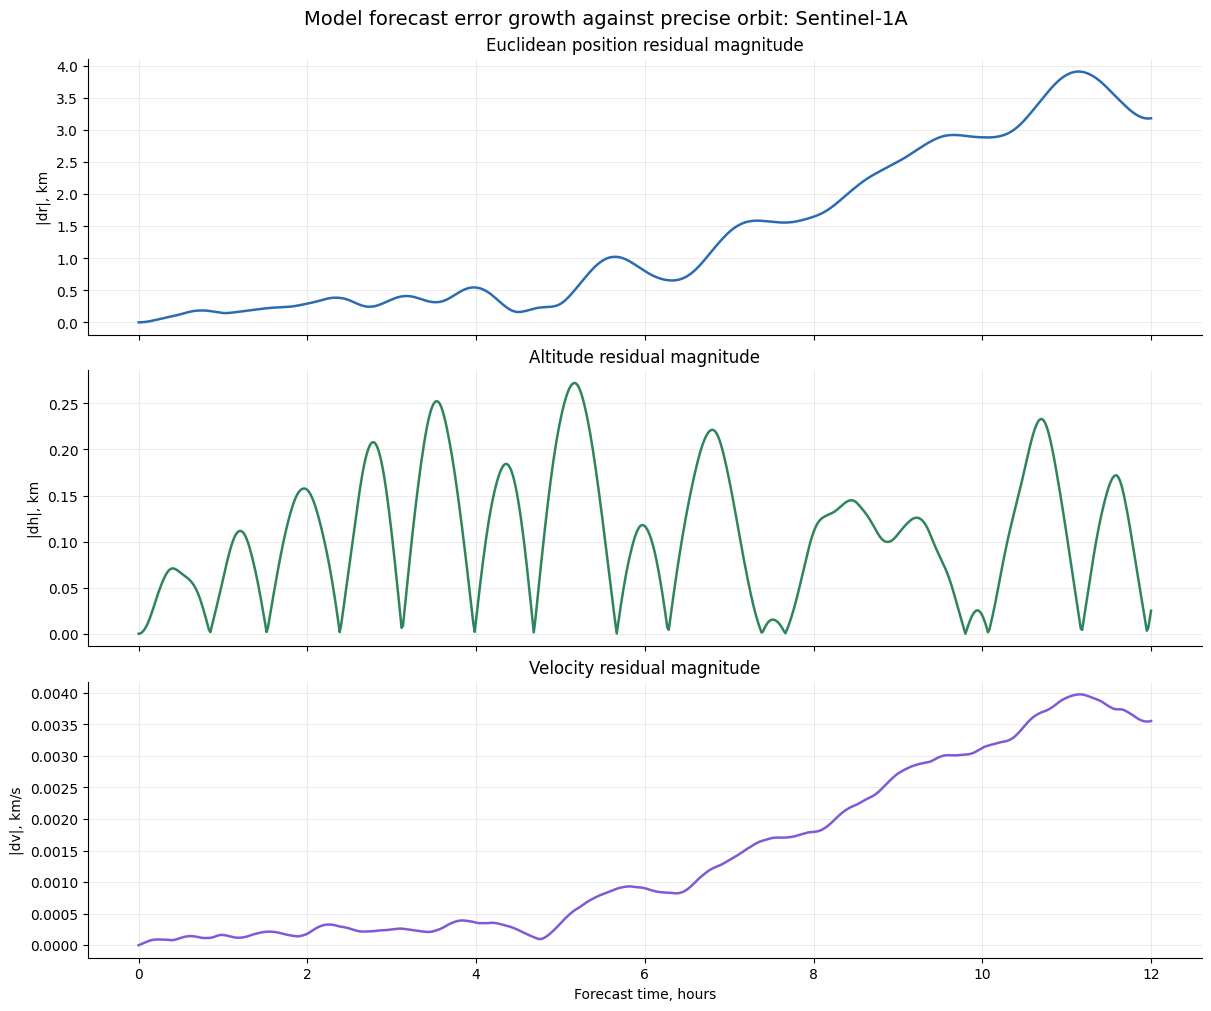

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, constrained_layout=True)

plot_style = {
    'position': {'color': '#2b6cb0', 'lw': 1.8},
    'altitude': {'color': '#2f855a', 'lw': 1.8},
    'velocity': {'color': '#805ad5', 'lw': 1.8},
}

axes[0].plot(t_hours, delta_r_km, **plot_style['position'])
axes[0].set_ylabel('|dr|, km')
axes[0].set_title('Euclidean position residual magnitude')

axes[1].plot(t_hours, delta_h_km, **plot_style['altitude'])
axes[1].set_ylabel('|dh|, km')
axes[1].set_title('Altitude residual magnitude')

axes[2].plot(t_hours, delta_v_km_s, **plot_style['velocity'])
axes[2].set_ylabel('|dv|, km/s')
axes[2].set_xlabel('Forecast time, hours')
axes[2].set_title('Velocity residual magnitude')

for ax in axes:
    ax.grid(True, alpha=0.25, linewidth=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(f'Model forecast error growth against precise orbit: {sat_name}', fontsize=14)
plt.show()


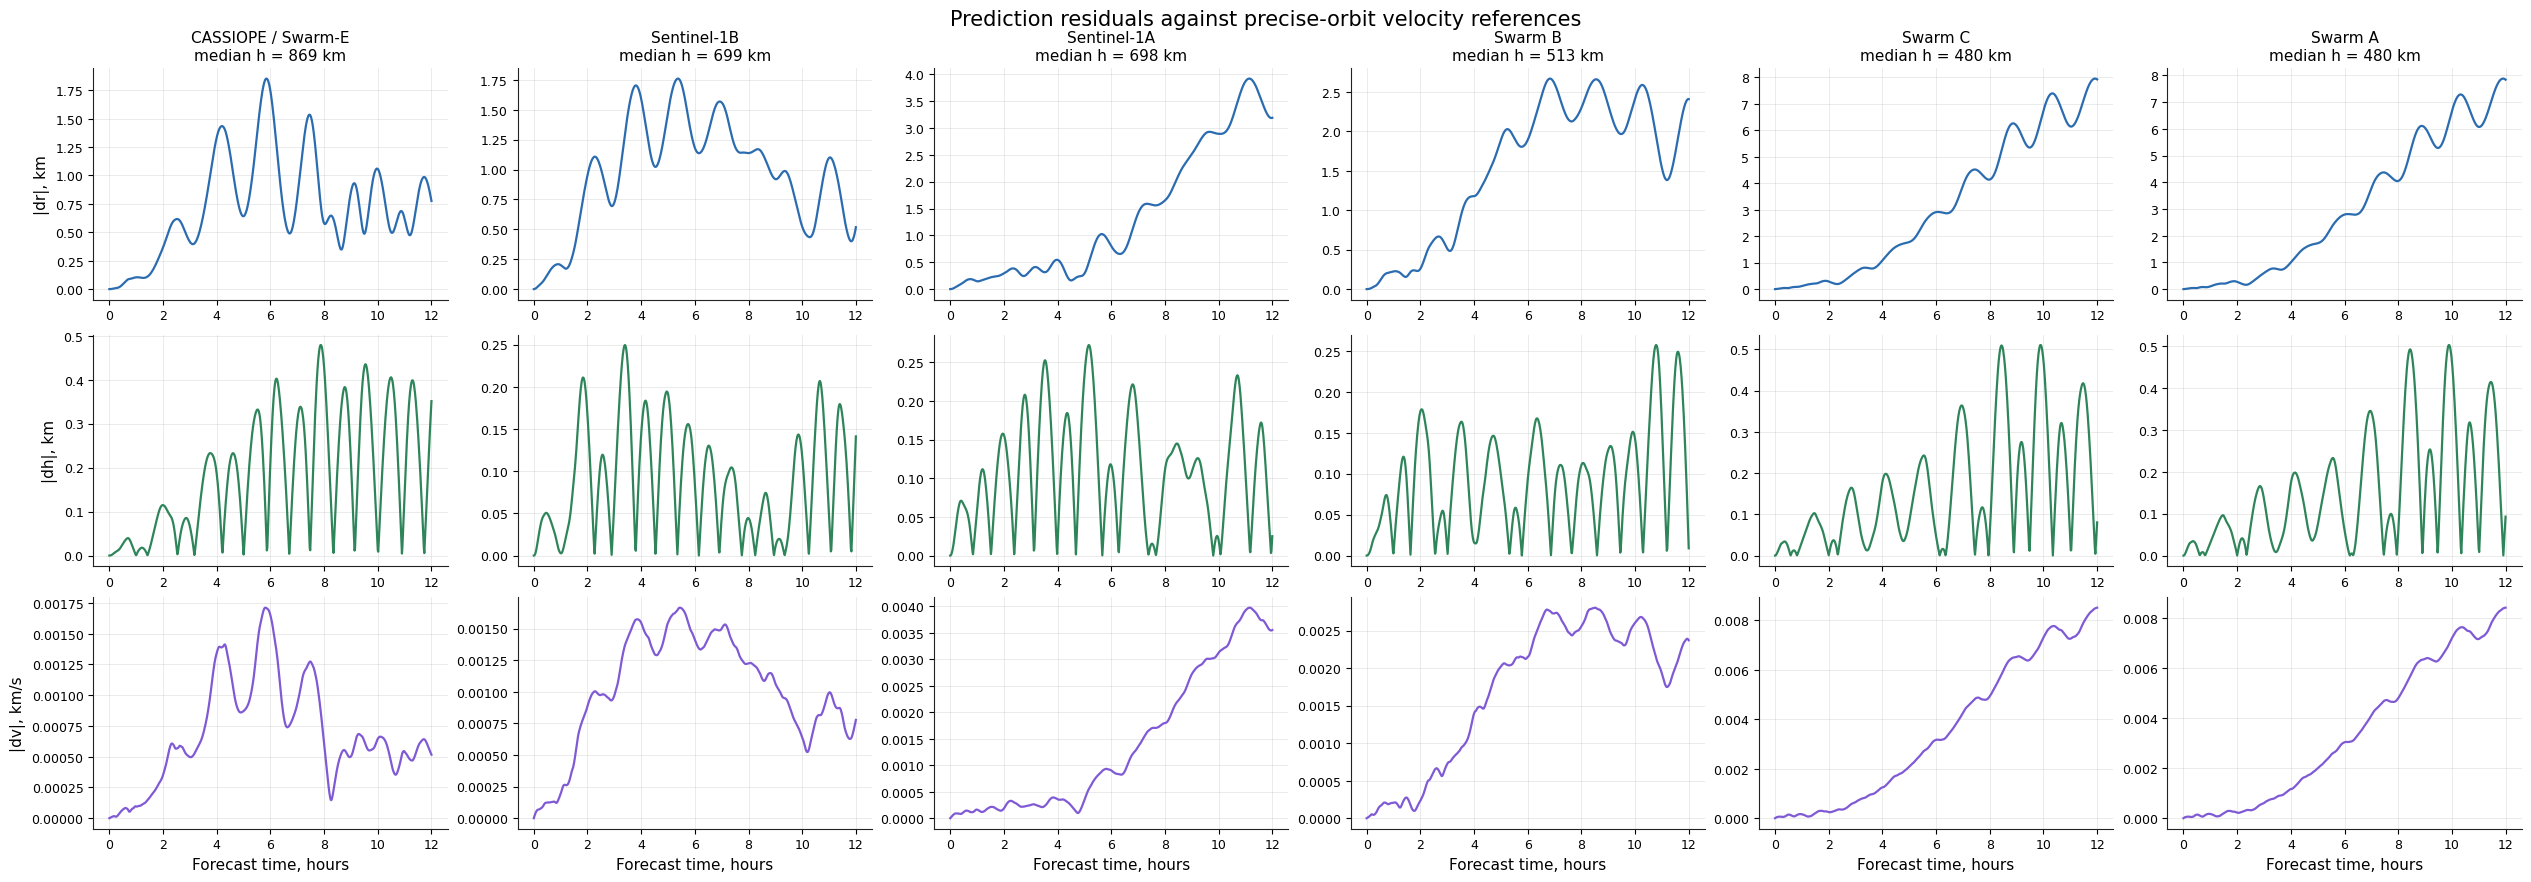

CASSIOPE / Swarm-E: native velocity = True, median h = 869.2 km, max |dr| = 1.85 km, max |dh| = 0.48 km, max |dv| = 0.0017 km/s
Sentinel-1B: native velocity = True, median h = 699.3 km, max |dr| = 1.76 km, max |dh| = 0.25 km, max |dv| = 0.0017 km/s
Sentinel-1A: native velocity = True, median h = 698.4 km, max |dr| = 3.92 km, max |dh| = 0.27 km, max |dv| = 0.0040 km/s
Swarm B: native velocity = True, median h = 513.4 km, max |dr| = 2.67 km, max |dh| = 0.26 km, max |dv| = 0.0028 km/s
Swarm C: native velocity = True, median h = 480.2 km, max |dr| = 7.96 km, max |dh| = 0.51 km, max |dv| = 0.0085 km/s
Swarm A: native velocity = True, median h = 480.2 km, max |dr| = 7.88 km, max |dh| = 0.50 km, max |dv| = 0.0084 km/s


In [7]:
all_errors = [
    compute_prediction_error(
        sat_name,
        source,
        horizon_h=forecast_horizon_h,
        step_s=step_seconds,
    )
    for sat_name, source in VELOCITY_REFERENCE_SOURCES.items()
]
all_errors.sort(key=lambda item: item['median_altitude_km'], reverse=True)

if not all(item['has_velocity'] for item in all_errors):
    missing = [item['name'] for item in all_errors if not item['has_velocity']]
    raise ValueError(f'Sources without native velocity records: {missing}')

n_sats = len(all_errors)
metric_rows = [
    ('delta_r_km', '|dr|, km', '#2b6cb0'),
    ('delta_h_km', '|dh|, km', '#2f855a'),
    ('delta_v_km_s', '|dv|, km/s', '#805ad5'),
]

with plt.rc_context({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#222222',
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'font.size': 10,
}):
    fig, axes = plt.subplots(
        len(metric_rows),
        n_sats,
        figsize=(4.2 * n_sats, 8.5),
        sharex=False,
        constrained_layout=True,
    )

    if n_sats == 1:
        axes = axes.reshape(len(metric_rows), 1)

    for col, item in enumerate(all_errors):
        for row, (metric_key, ylabel, color) in enumerate(metric_rows):
            ax = axes[row, col]
            y = np.maximum(item[metric_key], np.finfo(float).tiny)
            ax.plot(item['t_hours'], y, color=color, lw=1.6)
            ax.grid(True, alpha=0.25, linewidth=0.7)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            if col == 0:
                ax.set_ylabel(ylabel)
            if row == len(metric_rows) - 1:
                ax.set_xlabel('Forecast time, hours')
            if row == 0:
                ax.set_title(f'{item["name"]}\nmedian h = {item["median_altitude_km"]:.0f} km')

    fig.suptitle(
        'Prediction residuals against precise-orbit velocity references',
        fontsize=15,
        y=1.02,
    )
    plt.show()

for item in all_errors:
    print(
        f'{item["name"]}: native velocity = {item["has_velocity"]}, '
        f'median h = {item["median_altitude_km"]:.1f} km, '
        f'max |dr| = {item["delta_r_km"].max():.2f} km, '
        f'max |dh| = {item["delta_h_km"].max():.2f} km, '
        f'max |dv| = {item["delta_v_km_s"].max():.4f} km/s'
    )


In [8]:
experiment_records = [
    make_experiment_record(
        name=item['name'],
        source=item['source'],
        propagation_config=item['propagation_config'],
        reference_states=item['states_ref'],
        model_states=item['states_model'],
        extra={
            'reference_path': item['path'],
            'has_velocity': item['has_velocity'],
            'horizon_h': forecast_horizon_h,
            'step_seconds': step_seconds,
        },
    )
    for item in all_errors
]

summary_dir = PROJECT_ROOT / 'history' / 'prediction_error_growth_addition'
json_path, csv_path = write_experiment_summary(
    experiment_records,
    summary_dir,
    stem=f'prediction_error_growth_{int(forecast_horizon_h)}h_{int(step_seconds)}s',
)
print(f'Wrote summary JSON: {json_path}')
print(f'Wrote summary CSV: {csv_path}')


Wrote summary JSON: C:\Users\Gavriil\VS_projects\space_modeling\history\prediction_error_growth_addition\prediction_error_growth_12h_60s.json
Wrote summary CSV: C:\Users\Gavriil\VS_projects\space_modeling\history\prediction_error_growth_addition\prediction_error_growth_12h_60s.csv


In [9]:
# Опциональные конфигурации сил для исследования добавлений. Они перечислены здесь для
# ручных поочерёдных экспериментов, но этот ноутбук автоматически не запускает
# исследования влияния сил.
addition_force_configs = make_addition_force_configs()
egm_gravity_file = PROJECT_ROOT / 'data' / 'cache' / 'egm2008.gfc'

optional_scenarios = {
    name: {'force_models': force_models, 'gravity_coefficients_file': None}
    for name, force_models in addition_force_configs.items()
}
if egm_gravity_file.exists():
    egm_force_models = make_addition_force_configs()['recommended_baseline']
    egm_force_models.earth_gravity_model = 'egm2008'
    egm_force_models.gravity_max_degree = 8
    egm_force_models.gravity_max_order = 8
    optional_scenarios['plus_egm2008_degree8'] = {
        'force_models': egm_force_models,
        'gravity_coefficients_file': egm_gravity_file,
    }
else:
    print(f'Skipping EGM2008 optional scenario; local file not found: {egm_gravity_file}')

print('Available optional scenarios:')
for scenario_name in optional_scenarios:
    print(f'  - {scenario_name}')


Available optional scenarios:
  - recommended_baseline
  - plus_earth_ir
  - plus_relativity
  - plus_solid_earth_tides
  - plus_egm2008_degree8


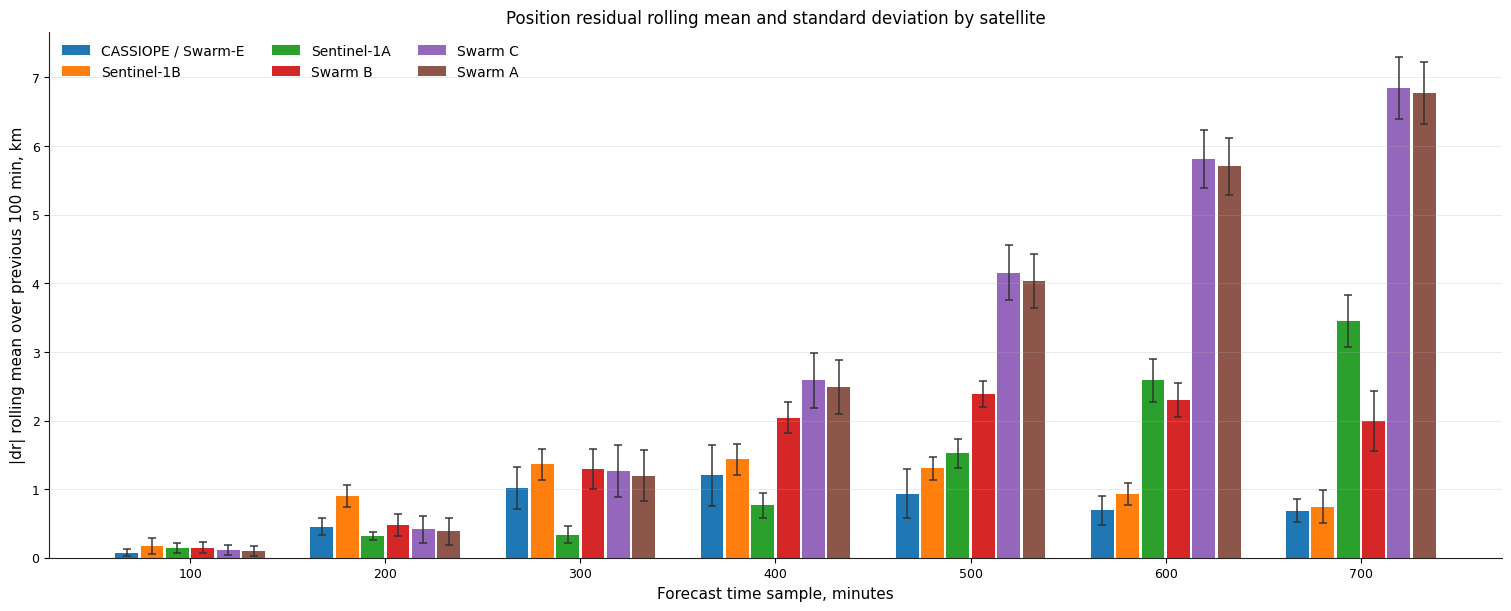

In [12]:
ROLLING_WINDOW_MINUTES = 100.0
GROUP_STEP_MINUTES = 100.0


def rolling_mean_std_at_targets(t_minutes, values, target_minutes, window_minutes=ROLLING_WINDOW_MINUTES):
    """Return mean and std over [target - window_minutes, target] for each target time."""
    t_minutes = np.asarray(t_minutes, dtype=float)
    values = np.asarray(values, dtype=float)
    target_minutes = np.asarray(target_minutes, dtype=float)
    means = np.full(target_minutes.shape, np.nan, dtype=float)
    stds = np.full(target_minutes.shape, np.nan, dtype=float)

    for index, t_current in enumerate(target_minutes):
        start_index = np.searchsorted(t_minutes, t_current - window_minutes, side='left')
        end_index = np.searchsorted(t_minutes, t_current, side='right')
        window = values[start_index:end_index]
        finite_window = window[np.isfinite(window)]
        if finite_window.size == 0:
            continue
        means[index] = finite_window.mean()
        stds[index] = finite_window.std(ddof=0)

    return means, stds


satellite_colors = {
    'CASSIOPE / Swarm-E': '#1f77b4',
    'Sentinel-1B': '#ff7f0e',
    'Sentinel-1A': '#2ca02c',
    'Swarm B': '#d62728',
    'Swarm C': '#9467bd',
    'Swarm A': '#8c564b',
}

n_sats = len(all_errors)
max_t_minutes = min(float(np.nanmax(item['t_hours']) * 60.0) for item in all_errors)
target_minutes = np.arange(GROUP_STEP_MINUTES, max_t_minutes + 0.5 * GROUP_STEP_MINUTES, GROUP_STEP_MINUTES)
bar_group_width_minutes = 0.78 * GROUP_STEP_MINUTES
bar_width_minutes = bar_group_width_minutes / max(n_sats, 1)
bar_offsets = (np.arange(n_sats) - (n_sats - 1) / 2.0) * bar_width_minutes

with plt.rc_context({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#222222',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'font.size': 10,
}):
    fig, ax = plt.subplots(figsize=(15, 6), constrained_layout=True)

    for sat_index, item in enumerate(all_errors):
        t_minutes = np.asarray(item['t_hours'], dtype=float) * 60.0
        rolling_mean_km, rolling_std_km = rolling_mean_std_at_targets(
            t_minutes,
            item['delta_r_km'],
            target_minutes,
            window_minutes=ROLLING_WINDOW_MINUTES,
        )

        color = satellite_colors.get(item['name'], f'C{sat_index}')
        ax.bar(
            target_minutes + bar_offsets[sat_index],
            rolling_mean_km,
            width=bar_width_minutes * 0.9,
            yerr=rolling_std_km,
            color=color,
            alpha=1.0,
            ecolor='#303030',
            error_kw={'elinewidth': 1.4, 'capthick': 1.4, 'alpha': 0.75, 'capsize': 3.0},
            linewidth=0,
            label=item['name'],
        )

    ax.set_xticks(target_minutes)
    ax.set_xlabel('Forecast time sample, minutes')
    ax.set_ylabel('|dr| rolling mean over previous 100 min, km')
    ax.set_title('Position residual rolling mean and standard deviation by satellite')
    ax.grid(True, axis='y', alpha=0.25, linewidth=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(ncol=3, frameon=False, loc='upper left')

    plt.show()

